In [1]:
import kagglehub
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Path to dataset files: /kaggle/input/telco-customer-churn


In [2]:
print(os.listdir(path))

['WA_Fn-UseC_-Telco-Customer-Churn.csv']


In [3]:
df = pd.read_csv(os.path.join(path, "WA_Fn-UseC_-Telco-Customer-Churn.csv"))
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [7]:
output_prop = df['Churn'].value_counts(normalize=True)*100
print(f"Churn Rate{output_prop.iloc[1]:.2f}%")

Churn Rate26.54%


In [8]:
df[df['TotalCharges'].str.strip() == ' ']
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [9]:
X = df.drop(columns = ["customerID","Churn"])
y = df["Churn"]

In [10]:
y = y.map({'No': 0, 'Yes': 1}).astype(int)

In [11]:
categorical_columns = X.select_dtypes(include = ["object","category"]).columns
df[categorical_columns].nunique()

,0
gender,2
Partner,2
Dependents,2
PhoneService,2
MultipleLines,3
InternetService,3
OnlineSecurity,3
OnlineBackup,3
DeviceProtection,3
TechSupport,3


In [12]:
df["TotalCharges"]

,TotalCharges
0,29.85
1,1889.50
2,108.15
3,1840.75
4,151.65
...,...
7038,1990.50
7039,7362.90
7040,346.45
7041,306.60


In [13]:
print(X.columns.tolist())

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


In [14]:
X = pd.get_dummies(X,columns = categorical_columns, drop_first = True)
len(X.columns)

30

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2, stratify = y, random_state = 42)
print(f"Check for invalids in training set: {X_train.isnull().sum().sum()}")
print(f"Check for invalids in testing set: {X_test.isnull().sum().sum()}")

Check for invalids in training set: 0
Check for invalids in testing set: 0


In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

preprocessor = ColumnTransformer(
    transformers=[('num', StandardScaler(), numeric_cols)],
    remainder='passthrough'  # leaves one-hot columns as-is
)

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import average_precision_score
from sklearn.metrics import confusion_matrix
log_reg_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', LogisticRegression(penalty = 'l1', solver = 'liblinear', class_weight = 'balanced'))
])
log_reg_pipe.fit(X_train, y_train)
y_pred_proba = log_reg_pipe.predict_proba(X_test)
pred_class = np.argmax(y_pred_proba, axis = 1)
pred_class

array([0, 1, 0, ..., 0, 0, 0])

In [18]:
pr_auc = average_precision_score(y_test, y_pred_proba[:, 1])
print(f"The PR-AUC score of the base logistic regression model is : {pr_auc:.2f}")

The PR-AUC score of the base logistic regression model is : 0.64


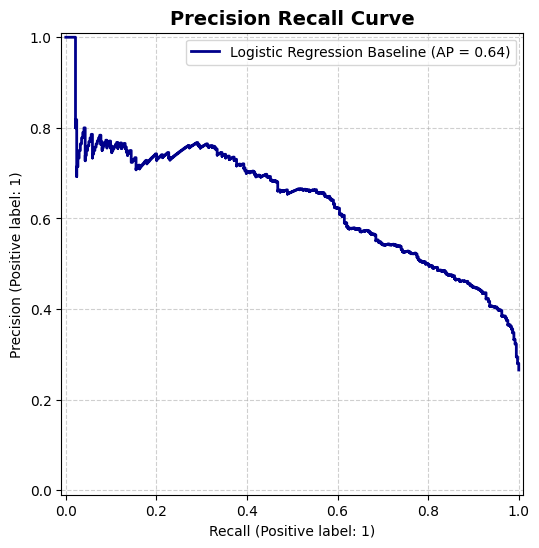

In [19]:
from sklearn.metrics import PrecisionRecallDisplay
fig,ax = plt.subplots(figsize = (8,6))
PrecisionRecallDisplay.from_predictions(
    y_test, y_pred_proba[:,1],
    name = "Logistic Regression Baseline", color = "darkblue", linewidth=2, ax=ax
)
ax.set_title("Precision Recall Curve", fontsize = 14, fontweight = "bold")
plt.grid(True, linestyle = "--", alpha = 0.6)
plt.legend(loc = "upper right")
plt.show()

In [20]:
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_recall_curve
def optimize_threshold_for_cost(y_true, y_probs, cost_fn=5, cost_fp=1):
  thresholds = np.linspace(0.01, 0.99, 99)
  costs = []
  for t in thresholds:
      preds = (y_probs >= t).astype(int)
      tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
      cost = fn * cost_fn + fp * cost_fp
      costs.append(cost)
  best_t = thresholds[np.argmin(costs)]
  return best_t
def analyse_best_threshold(y_test, y_pred_proba, use):
    print("======Blind 0.5=====")
    pred_class = (y_pred_proba[:, 1] >= 0.5).astype(int)
    print(f"Confusion_matrix at threshold 0.5:\n{confusion_matrix(y_test, pred_class)}")
    print(f"Recall: {recall_score(y_test, pred_class, average=None)[1]:.2f}")
    print(f"F1: {f1_score(y_test, pred_class):.4f}")

    print("======F1-OPTIMAL=====")
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba[:, 1])
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
    f1_best_threshold = thresholds[np.argmax(f1_scores)]
    pred_class = (y_pred_proba[:,1]>=f1_best_threshold).astype(int)
    print(f"F1-optimal threshold: {f1_best_threshold:.2f}")
    print(f"Confusion_matrix at threshold {f1_best_threshold:.2f}:\n{confusion_matrix(y_test, pred_class)}")
    print(f"Recall: {recall_score(y_test, pred_class, average=None)[1]:.2f}")
    print(f"F1_score:{np.max(f1_scores):.2f}")

    print("======BUSINESS COST=====")
    cost_best_threshold = optimize_threshold_for_cost(y_test, y_pred_proba[:, 1])
    pred_class = (y_pred_proba[:, 1] >= cost_best_threshold).astype(int)
    print(f"Confusion_matrix at threshold {cost_best_threshold:.2f}:\n{confusion_matrix(y_test, pred_class)}")
    print(f"Recall: {recall_score(y_test, pred_class, average=None)[1]:.2f}")
    print(f"F1: {f1_score(y_test, pred_class):.4f}")
    print("===============")
    return cost_best_threshold if use == 'cost' else f1_best_threshold

best_threshold = analyse_best_threshold(y_test, y_pred_proba,'cost')
pred_class = (y_pred_proba[:,1]>=best_threshold).astype(int)
print(f"Confusion_matrix at threshold {best_threshold:.2f}: {confusion_matrix(y_test, pred_class)}")
print(f"With a recall of: {recall_score(y_test, pred_class, average=None)[1]:0.2f}")
print(f"And the corresponding F1 score is: {f1_score(y_test, pred_class, average='binary'):.4f}")
print(f"The PR-AUC score: {average_precision_score(y_test,y_pred_proba[:,1]):.2f}")

======Blind 0.5=====
Confusion_matrix at threshold 0.5:
[[745 290]
 [ 79 295]]
Recall: 0.79
F1: 0.6152
======F1-OPTIMAL=====
F1-optimal threshold: 0.53
Confusion_matrix at threshold 0.53:
[[772 263]
 [ 85 289]]
Recall: 0.77
F1_score:0.62
======BUSINESS COST=====
Confusion_matrix at threshold 0.31:
[[584 451]
 [ 27 347]]
Recall: 0.93
F1: 0.5922
Confusion_matrix at threshold 0.31: [[584 451]
 [ 27 347]]
With a recall of: 0.93
And the corresponding F1 score is: 0.5922
The PR-AUC score: 0.64


In [21]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = [
    {'penalty': ['l1'], 'solver': ['liblinear'], 'class_weight': ['balanced'], 'C': [0.01, 0.1, 1, 10]},
    {'penalty': ['l2'], 'solver': ['liblinear', 'lbfgs'], 'class_weight': ['balanced'], 'C': [0.01, 0.1, 1, 10]},
]
log_reg_cv = LogisticRegression()
search = RandomizedSearchCV(
    estimator = log_reg_cv,
    param_distributions = param_dist,
    n_iter = 10,
    cv = 3,
    scoring = "average_precision",
    random_state = 42,
    n_jobs = 1
)
log_reg_pipe_cv = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', search)
])
log_reg_pipe_cv.fit(X_train, y_train)
print(f"The best params are: {search.best_params_}")
print(f"The best PR-AUC Score is: {search.best_score_:0.2f}")
best_model = search.best_estimator_

The best params are: {'solver': 'liblinear', 'penalty': 'l1', 'class_weight': 'balanced', 'C': 1}
The best PR-AUC Score is: 0.66


In [22]:
y_pred_proba = log_reg_pipe_cv.predict_proba(X_test)
best_threshold_cv = analyse_best_threshold(y_test,y_pred_proba,'cost')
pred_class = (y_pred_proba[:,1]>=best_threshold_cv)
print(f"The PR-AUC score: {average_precision_score(y_test,y_pred_proba[:,1]):.2f}")

======Blind 0.5=====
Confusion_matrix at threshold 0.5:
[[745 290]
 [ 79 295]]
Recall: 0.79
F1: 0.6152
======F1-OPTIMAL=====
F1-optimal threshold: 0.53
Confusion_matrix at threshold 0.53:
[[772 263]
 [ 85 289]]
Recall: 0.77
F1_score:0.62
======BUSINESS COST=====
Confusion_matrix at threshold 0.31:
[[584 451]
 [ 27 347]]
Recall: 0.93
F1: 0.5922
The PR-AUC score: 0.64


In [23]:
from sklearn.ensemble import RandomForestClassifier
rf_base = RandomForestClassifier(max_depth = 10, n_estimators = 10, class_weight = "balanced", min_samples_split = 5)
rf_base.fit(X_train, y_train)
y_pred_proba_rf_base = rf_base.predict_proba(X_test)
pr_auc_rf_base = average_precision_score(y_test, y_pred_proba_rf_base[:,1])
print(f"The PR_AUC score of base random forest model: {pr_auc_rf_base:.2f}")

The PR_AUC score of base random forest model: 0.64


In [24]:
best_threshold_cv = analyse_best_threshold(y_test,y_pred_proba_rf_base,'cost')
print(f"The PR_AUC score of base random forest model: {pr_auc_rf_base:.2f}")

======Blind 0.5=====
Confusion_matrix at threshold 0.5:
[[786 249]
 [ 94 280]]
Recall: 0.75
F1: 0.6202
======F1-OPTIMAL=====
F1-optimal threshold: 0.54
Confusion_matrix at threshold 0.54:
[[827 208]
 [108 266]]
Recall: 0.71
F1_score:0.63
======BUSINESS COST=====
Confusion_matrix at threshold 0.34:
[[668 367]
 [ 54 320]]
Recall: 0.86
F1: 0.6032
The PR_AUC score of base random forest model: 0.64


In [25]:
param_dist_rf = [
    { 'max_depth':[10,30,50,100],
      'n_estimators':[50,100,200,300],
      'class_weight':['balanced'],
      'min_samples_split':[2,5,10]
    }
]
rf_cv = RandomForestClassifier(random_state = 42)
search_rf = RandomizedSearchCV(
    estimator = rf_cv,
    param_distributions = param_dist_rf,
    n_iter = 40,
    cv = 3,
    scoring = "average_precision",
    random_state = 42,
    n_jobs = -1
)
rf_pipe_cv = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', search_rf)
])
rf_pipe_cv.fit(X_train, y_train)
print(f"The best params are: {search_rf.best_params_}")
print(f"The best PR-AUC Score is: {search_rf.best_score_:0.2f}")
best_model_rf = search_rf.best_estimator_

The best params are: {'n_estimators': 300, 'min_samples_split': 10, 'max_depth': 10, 'class_weight': 'balanced'}
The best PR-AUC Score is: 0.66


In [26]:
y_pred_proba_rf = rf_pipe_cv.predict_proba(X_test)
best_threshold_rf = analyse_best_threshold(y_test, y_pred_proba_rf, "cost")
test_pr_auc_rf = average_precision_score(y_test, y_pred_proba_rf[:, 1])
print(f"RF test PR-AUC: {test_pr_auc_rf:.2f}")

======Blind 0.5=====
Confusion_matrix at threshold 0.5:
[[793 242]
 [ 94 280]]
Recall: 0.75
F1: 0.6250
======F1-OPTIMAL=====
F1-optimal threshold: 0.47
Confusion_matrix at threshold 0.47:
[[776 259]
 [ 79 295]]
Recall: 0.79
F1_score:0.64
======BUSINESS COST=====
Confusion_matrix at threshold 0.37:
[[712 323]
 [ 55 319]]
Recall: 0.85
F1: 0.6280
RF test PR-AUC: 0.66


In [27]:
pip install lightgbm

In [28]:
import lightgbm as lgb
from lightgbm import LGBMClassifier
# 1. Fit preprocessor ONCE on the full training set
preprocessor.fit(X_train)
X_train_proc = preprocessor.transform(X_train)

# 2. Split the already-preprocessed data into train/val for early stopping
X_tr_proc, X_val_proc, y_tr, y_val = train_test_split(
    X_train_proc, y_train, test_size=0.2, stratify=y_train, random_state=42
)

# 3. Fit LightGBM with early stopping
scale_pos_weight = (y_tr == 0).sum() / (y_tr == 1).sum()

lgbm = LGBMClassifier(scale_pos_weight=scale_pos_weight, random_state=42, n_estimators=1000)

lgbm.fit(
    X_tr_proc, y_tr,
    eval_set=[(X_val_proc, y_val)],
    eval_metric='average_precision',
    callbacks=[lgb.early_stopping(stopping_rounds=50)]
)

print(f"Best iteration: {lgbm.best_iteration_}")

# 4. Assemble the final pipeline using the SAME already-fitted preprocessor + already-fitted lgbm
lgbm_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', lgbm)
])

[LightGBM] [Info] Number of positive: 1196, number of negative: 3311
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000481 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 638
[LightGBM] [Info] Number of data points in the train set: 4507, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265365 -> initscore=-1.018268
[LightGBM] [Info] Start training from score -1.018268
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[8]	valid_0's average_precision: 0.665286	valid_0's binary_logloss: 0.465557
Best iteration: 8


In [29]:
y_pred_proba_lgbm = lgbm_pipe.predict_proba(X_test)
best_threshold_lgbm = analyse_best_threshold(y_test, y_pred_proba_lgbm, "cost")
print(f"LightGBM test PR-AUC: {average_precision_score(y_test, y_pred_proba_lgbm[:,1]):.2f}")

======Blind 0.5=====
Confusion_matrix at threshold 0.5:
[[867 168]
 [141 233]]
Recall: 0.62
F1: 0.6013
======F1-OPTIMAL=====
F1-optimal threshold: 0.46
Confusion_matrix at threshold 0.46:
[[834 201]
 [113 261]]
Recall: 0.70
F1_score:0.62
======BUSINESS COST=====
Confusion_matrix at threshold 0.28:
[[580 455]
 [ 32 342]]
Recall: 0.91
F1: 0.5841
LightGBM test PR-AUC: 0.64


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [30]:
y_proba_logreg = log_reg_pipe_cv.predict_proba(X_test)[:, 1]
y_proba_rf     = rf_pipe_cv.predict_proba(X_test)[:, 1]
y_proba_lgbm   = lgbm_pipe.predict_proba(X_test)[:, 1]

y_proba_ensemble = (y_proba_logreg + y_proba_rf + y_proba_lgbm) / 3

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [31]:
y_pred_proba_ensemble = np.column_stack([1 - y_proba_ensemble, y_proba_ensemble])  # match the [:, 1] shape your function expects

best_threshold_ens = analyse_best_threshold(y_test, y_pred_proba_ensemble, "cost")
print(f"Ensemble test PR-AUC: {average_precision_score(y_test, y_proba_ensemble):.2f}")

======Blind 0.5=====
Confusion_matrix at threshold 0.5:
[[804 231]
 [ 93 281]]
Recall: 0.75
F1: 0.6343
======F1-OPTIMAL=====
F1-optimal threshold: 0.48
Confusion_matrix at threshold 0.48:
[[782 253]
 [ 80 294]]
Recall: 0.79
F1_score:0.64
======BUSINESS COST=====
Confusion_matrix at threshold 0.26:
[[557 478]
 [ 23 351]]
Recall: 0.94
F1: 0.5835
Ensemble test PR-AUC: 0.65


In [32]:
!pip install joblib
import joblib

joblib.dump(lgbm_pipe, 'churn_model_pipeline.joblib')

# Save a template row so Streamlit knows the exact column structure expected
template_row = X_train.iloc[[0]].copy()
joblib.dump(template_row, 'template_row.joblib')

# Save your chosen threshold from the cost-optimizer
best_threshold = 0.31  # replace with whatever you locked in for LightGBM specifically
joblib.dump(best_threshold, 'best_threshold.joblib')

['best_threshold.joblib']

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


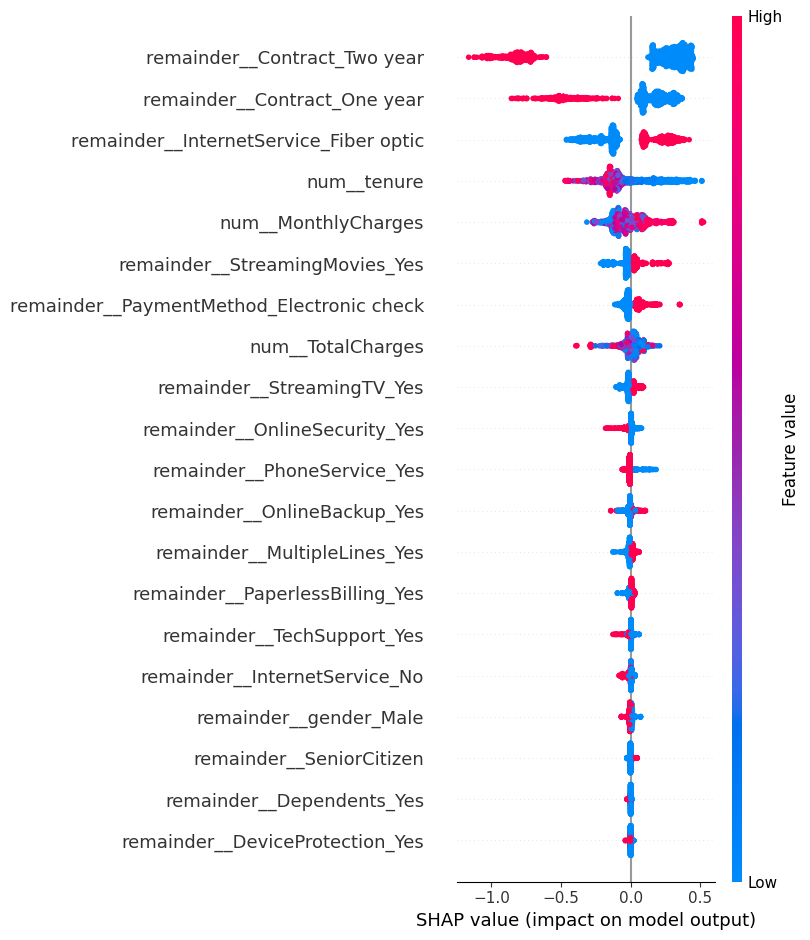

In [33]:
import shap

# Extract just the trained LightGBM model out of the pipeline for SHAP
lgbm_model = lgbm_pipe.named_steps['clf']
X_test_transformed = lgbm_pipe.named_steps['preprocessor'].transform(X_test)

explainer = shap.TreeExplainer(lgbm_model)
shap_values = explainer.shap_values(X_test_transformed)

# Global importance — which features matter most overall
shap.summary_plot(shap_values, X_test_transformed, feature_names=lgbm_pipe.named_steps['preprocessor'].get_feature_names_out())

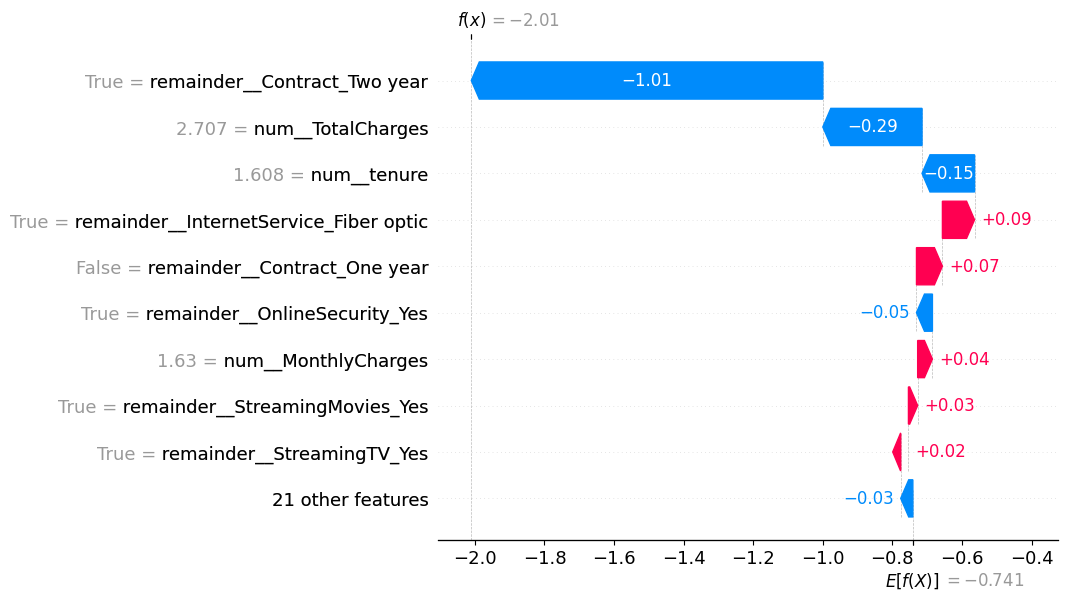

In [34]:
shap.plots.waterfall(shap.Explanation(
    values=shap_values[0],
    base_values=explainer.expected_value,
    data=X_test_transformed[0],
    feature_names=lgbm_pipe.named_steps['preprocessor'].get_feature_names_out()
))

In [35]:
from google.colab import files

files.download('churn_model_pipeline.joblib')
files.download('best_threshold.joblib')
files.download('template_row.joblib')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [36]:
import sklearn
print(sklearn.__version__)

1.6.1


In [37]:
import lightgbm
print(lightgbm.__version__)

4.6.0


In [38]:
import pandas as pd
from sklearn.metrics import average_precision_score, recall_score, precision_score, f1_score

def evaluate_model(name, y_true, y_pred_proba, threshold):
    pred_class = (y_pred_proba >= threshold).astype(int)
    return {
        "Model": name,
        "Threshold": round(threshold, 2),
        "PR-AUC": round(average_precision_score(y_true, y_pred_proba), 3),
        "Recall (churn)": round(recall_score(y_true, pred_class), 3),
        "Precision (churn)": round(precision_score(y_true, pred_class), 3),
        "F1": round(f1_score(y_true, pred_class), 3),
    }

results = []

# --- Logistic Regression ---
proba_logreg = log_reg_pipe_cv.predict_proba(X_test)[:, 1]
thresh_logreg = optimize_threshold_for_cost(y_test, proba_logreg)
results.append(evaluate_model("Logistic Regression", y_test, proba_logreg, thresh_logreg))

# --- Random Forest ---
proba_rf = rf_pipe_cv.predict_proba(X_test)[:, 1]
thresh_rf = optimize_threshold_for_cost(y_test, proba_rf)
results.append(evaluate_model("Random Forest", y_test, proba_rf, thresh_rf))

# --- LightGBM ---
proba_lgbm = lgbm_pipe.predict_proba(X_test)[:, 1]
thresh_lgbm = optimize_threshold_for_cost(y_test, proba_lgbm)
results.append(evaluate_model("LightGBM", y_test, proba_lgbm, thresh_lgbm))

# --- Soft-voting ensemble ---
proba_ensemble = (proba_logreg + proba_rf + proba_lgbm) / 3
thresh_ensemble = optimize_threshold_for_cost(y_test, proba_ensemble)
results.append(evaluate_model("Soft-Voting Ensemble", y_test, proba_ensemble, thresh_ensemble))

comparison_df = pd.DataFrame(results)
comparison_df

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Model,Threshold,PR-AUC,Recall (churn),Precision (churn),F1
0,Logistic Regression,0.31,0.636,0.928,0.435,0.592
1,Random Forest,0.37,0.656,0.853,0.497,0.628
2,LightGBM,0.28,0.635,0.914,0.429,0.584
3,Soft-Voting Ensemble,0.26,0.651,0.939,0.423,0.584
